In [36]:
import numpy as np
import pandas as pd
from snowflake_info import df
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
df = df.drop(columns='DATE')


x = df.drop(columns=['PRICE','SQFT_LOT','CONDITION','YEAR_BUILT','ZIPCODE','LONG','SQFT_LOT15'])
y = df['PRICE'].astype(float)

x_train, x_test, y_train, y_test =train_test_split(x , y, test_size=0.2, random_state=42)


make_poly  = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

make_poly.fit(x_train, y_train)

y_pred = make_poly.predict(x_test)

print(r2_score(y_test, y_pred))

df.corr()['PRICE']










0.7153562351337309


BEDROOMS          0.308350
BATHROOMS         0.475331
SQFT_LIVING       0.702035
SQFT_LOT          0.089661
FLOORS            0.258001
WATERFRONT        0.266369
VIEW              0.397293
CONDITION         0.036362
GRADE             0.292309
SQFT_ABOVE        0.605567
SQFT_BASEMENT     0.323816
YEAR_BUILT        0.054012
YEAR_RENOVATED    0.126434
ZIPCODE          -0.053203
PRICE             1.000000
LAT               0.307003
LONG              0.021626
SQFT_LIVING15     0.585379
SQFT_LOT15        0.082447
Name: PRICE, dtype: float64

ZIPCODE      int32
PRICE      float64
dtype: object


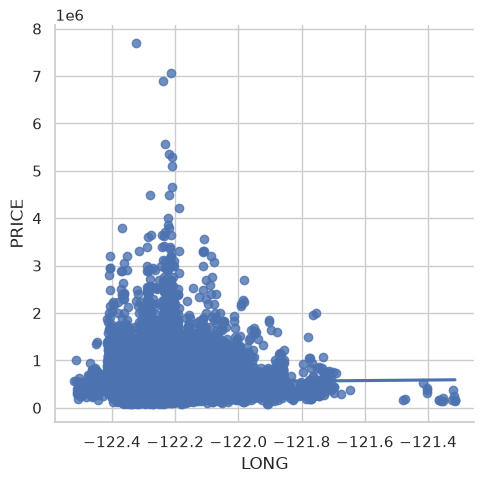

In [32]:
# 1. Check your data types. If ZIPCODE or PRICE says "object", that is your culprit.
print(df[['ZIPCODE', 'PRICE']].dtypes)

# 2. Force both columns to be numbers
df['PRICE'] = pd.to_numeric(df['PRICE'], errors='coerce')
df['LONG'] = pd.to_numeric(df['LONG'], errors='coerce')

# 3. Now the plot will run without throwing a TypeError!
sns.lmplot(x='LONG', y='PRICE', data=df, fit_reg=True, ci=None)